# Monte Carlo VaR and ES Simulation
 
**Stage:** Portfolio risk estimation via Monte Carlo simulation

## Objectives
1. Load fitted copulas (Gaussian and Student-t) from Notebook 03
2. Load fitted GARCH models from Notebook 02
3. Simulate 100,000 joint portfolio return scenarios from each copula
4. Compute VaR at 95% and 99% confidence levels
5. Compute ES at 97.5% confidence level
6. Compare risk estimates across models
7. Visualise simulated portfolio return distributions
8. Save VaR/ES estimates for backtesting 

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
from scipy import stats as stats_scipy

from src.garch_utils import fit_all_marginals
from src.var_engine import monte_carlo_var, compute_var_es

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
# Load prices and recompute returns
prices = pd.read_csv('../data/raw/prices.csv', 
                     index_col='Date', parse_dates=True)
returns = np.log(prices / prices.shift(1)).dropna()
train = returns.loc[:'2022-12-31']

print(f"Training data: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Observations: {len(train)}\n")


Training data: 2010-01-05 to 2022-12-30
Observations: 3281



In [3]:
# Refit GARCH models on training data
print("Refitting GARCH models...")
garch_results = fit_all_marginals(train, dist='studentst')
asset_names = list(garch_results.keys())
print(f"\nAssets: {asset_names}")

Refitting GARCH models...
Fitting GJR-GARCH for FTSE100...
  AIC: 8313.61  |  BIC: 8356.28

Fitting GJR-GARCH for GBPUSD...
  AIC: 5103.93  |  BIC: 5146.60

Fitting GJR-GARCH for Brent...
  AIC: 13294.77  |  BIC: 13337.44


Assets: ['FTSE100', 'GBPUSD', 'Brent']


In [5]:
#Load Fitted Copulas
with open('../data/raw/gaussian_copula.pkl', 'rb') as f:
    gaussian_copula = pickle.load(f)

with open('../data/raw/student_copula.pkl', 'rb') as f:
    student_copula = pickle.load(f)

print(f"Gaussian copula loaded — R shape: {gaussian_copula.R.shape}")
print(f"Student-t copula loaded — nu: {student_copula.nu}, R shape: {student_copula.R.shape}") 

Gaussian copula loaded — R shape: (3, 3)
Student-t copula loaded — nu: 5, R shape: (3, 3)


### 1. Monte Carlo Simulation Framework

The simulation pipeline for each copula:

**Step 1 — Simulate from copula**
$$\mathbf{u}^{(s)} = (u_1^{(s)}, u_2^{(s)}, u_3^{(s)}) \sim C(\cdot)$$

Draw $S = 100,000$ joint uniform scenarios from the fitted copula, 
preserving the dependence structure.

**Step 2 — Inverse PIT: uniforms → standardised residuals**
$$z_i^{(s)} = F_{t_{\nu_i}}^{-1}(u_i^{(s)})$$

Transform each uniform back through the inverse Student-t CDF 
using the asset-specific $\nu_i$ from the GARCH model.

**Step 3 — Scale by conditional volatility**
$$r_i^{(s)} = \mu_i + \hat{\sigma}_i \cdot z_i^{(s)}$$

where $\hat{\sigma}_i$ is the last fitted conditional volatility 
from the GARCH model.

**Step 4 — Portfolio return**
$$r_p^{(s)} = \sum_{i=1}^{3} w_i \cdot r_i^{(s)}, \qquad w_i = \frac{1}{3}$$

**Step 5 — VaR and ES**
$$\text{VaR}_\alpha = -q_{1-\alpha}(r_p)$$
$$\text{ES}_\alpha = -\mathbb{E}[r_p \mid r_p < -\text{VaR}_\alpha]$$

In [8]:
N_SIMULATIONS = 100_000
WEIGHTS = np.array([1/3, 1/3, 1/3])
ALPHA_LEVELS = [0.95, 0.99]
SEED = 42

print("Running Monte Carlo simulations...\n")

# Gaussian copula simulation
print("1. Gaussian Copula...")
gaussian_results = monte_carlo_var(
    copula=gaussian_copula,
    garch_results=garch_results,
    asset_names=asset_names,
    weights=WEIGHTS,
    n_simulations=N_SIMULATIONS,
    alpha_levels=ALPHA_LEVELS,
    seed=SEED,
)
print("   Completed.")

# Student-t copula simulation
print("2. Student-t Copula...")
student_results = monte_carlo_var(
    copula=student_copula,
    garch_results=garch_results,
    asset_names=asset_names,
    weights=WEIGHTS,
    n_simulations=N_SIMULATIONS,
    alpha_levels=ALPHA_LEVELS,
    seed=SEED,
)
print("   Completed.")
print("Simulations complete.")
print(f"Portfolio returns simulated: {N_SIMULATIONS:,} scenarios per model")
print(f"Equal weights: {WEIGHTS}")

Running Monte Carlo simulations...

1. Gaussian Copula...
   Completed.
2. Student-t Copula...
   Completed.
Simulations complete.
Portfolio returns simulated: 100,000 scenarios per model
Equal weights: [0.33333333 0.33333333 0.33333333]


### 2. Historical Simulation Benchmark

Historical Simulation (HS) is the simplest possible VaR model — 
it uses the empirical distribution of past returns directly with 
no parametric assumptions. We include it as a naive benchmark 
to compare against both copula models.

In [7]:
# Historical Simulation VaR benchmark
train_portfolio = (train * (1/3)).sum(axis=1)

hs_var_es = compute_var_es(
    train_portfolio.values,
    alpha_levels=ALPHA_LEVELS
)

print("Historical Simulation VaR/ES (training period):")
print(hs_var_es)

Historical Simulation VaR/ES (training period):
                       VaR        ES
Confidence Level                    
95%               0.015205  0.023917
99%               0.027447  0.041813


In [10]:
#VaR and ES Results Comparison
print("=" * 65)
print("Portfolio VaR and ES — Model Comparison")
print("Equal-weighted portfolio: FTSE100 / GBP-USD / Brent")
print("=" * 65)

for alpha in ALPHA_LEVELS:
    conf = f"{int(alpha*100)}%"
    print(f"\n--- Confidence Level: {conf} ---")
    print(f"{'Model':<25} {'VaR':>10} {'ES':>10}")
    print("-" * 48)

    g_var = gaussian_results['var_es_table'].loc[conf, 'VaR']
    g_es  = gaussian_results['var_es_table'].loc[conf, 'ES']
    t_var = student_results['var_es_table'].loc[conf, 'VaR']
    t_es  = student_results['var_es_table'].loc[conf, 'ES']
    h_var = hs_var_es.loc[conf, 'VaR']
    h_es  = hs_var_es.loc[conf, 'ES']

    print(f"{'Historical Simulation':<25} {h_var:>10.4f} {h_es:>10.4f}")
    print(f"{'Gaussian Copula':<25} {g_var:>10.4f} {g_es:>10.4f}")
    print(f"{'Student-t Copula':<25} {t_var:>10.4f} {t_es:>10.4f}")

    print(f"\n  Student-t vs Gaussian VaR difference: "
          f"{((t_var - g_var)/g_var)*100:+.2f}%")
    print(f"  Student-t vs Gaussian ES  difference: "
          f"{((t_es - g_es)/g_es)*100:+.2f}%")

Portfolio VaR and ES — Model Comparison
Equal-weighted portfolio: FTSE100 / GBP-USD / Brent

--- Confidence Level: 95% ---
Model                            VaR         ES
------------------------------------------------
Historical Simulation         0.0152     0.0239
Gaussian Copula               0.0178     0.0243
Student-t Copula              0.0177     0.0248

  Student-t vs Gaussian VaR difference: -0.57%
  Student-t vs Gaussian ES  difference: +1.91%

--- Confidence Level: 99% ---
Model                            VaR         ES
------------------------------------------------
Historical Simulation         0.0274     0.0418
Gaussian Copula               0.0281     0.0354
Student-t Copula              0.0290     0.0373

  Student-t vs Gaussian VaR difference: +3.02%
  Student-t vs Gaussian ES  difference: +5.38%


**95% confidence level**
- All three models produce similar VaR estimates (~1.5–1.8%)
- The Student-t and Gaussian copulas are nearly identical at this level 
  (VaR difference of -0.57%)
- This is expected — at moderate confidence levels, tail dependence has 
  limited impact since we are not yet in the extreme tail region

**99% confidence level — where tail dependence matters**
- The Student-t copula produces a VaR of 2.90% vs 2.81% for the Gaussian — 
  a difference of +3.02%
- The ES difference is more pronounced: 3.73% vs 3.54% — a difference of +5.38%
- ES captures the severity of losses beyond VaR, so the larger ES gap 
  reflects the Student-t copula's heavier joint tails

**Why ES shows a larger difference than VaR**
- VaR is a single quantile — it measures where the tail begins
- ES is an average over the entire tail beyond VaR — it is more sensitive 
  to the shape of the extreme tail
- The Student-t copula assigns more probability mass to extreme joint crashes, 
  which raises the average loss in the tail more than it raises the threshold

**Historical Simulation comparison**
- HS produces the lowest VaR at both confidence levels but the highest ES at 99%
- The high HS ES at 99% (4.18%) reflects the extreme realised losses during 
  the COVID crash and 2008 GFC that are directly embedded in the training data
- The copula models produce lower ES because they are parametric — 
  they smooth the return distribution rather than using raw historical scenarios

### 3. Portfolio Return Distribution


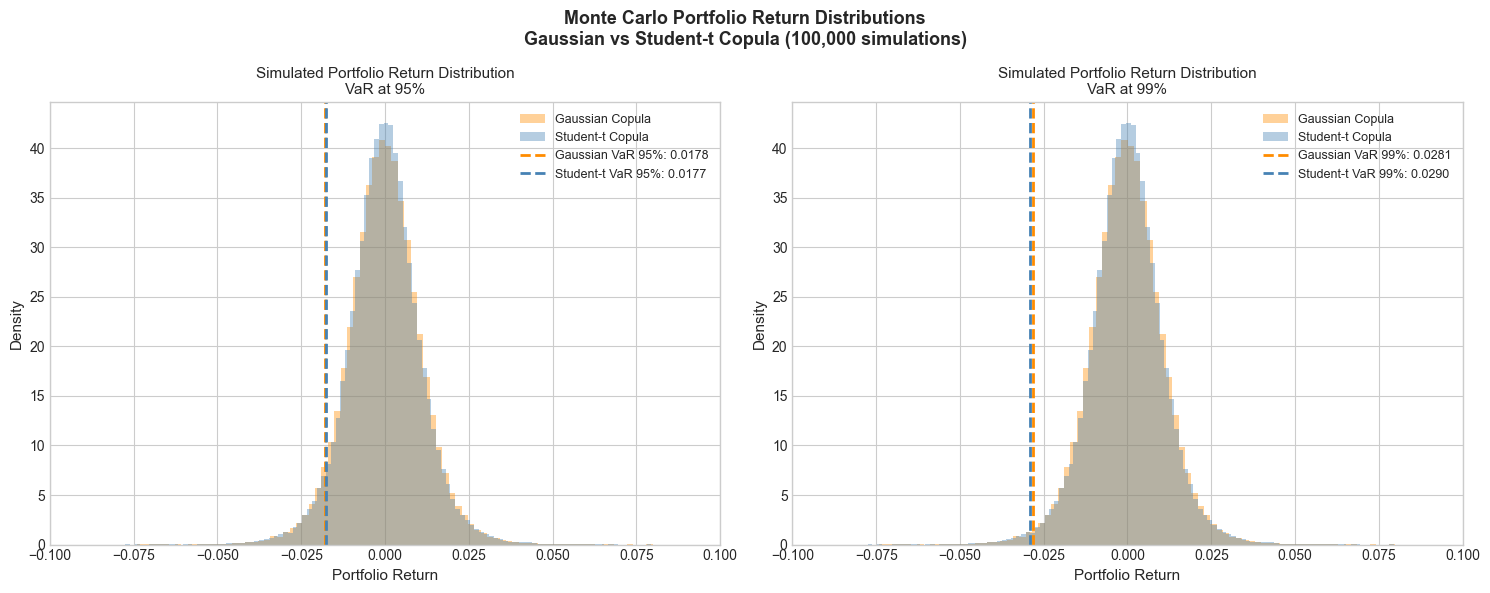

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

g_returns = gaussian_results['portfolio_returns']
t_returns = student_results['portfolio_returns']

for ax_idx, (alpha, conf) in enumerate(zip(ALPHA_LEVELS, ['95%', '99%'])):
    ax = axes[ax_idx]

    g_var = gaussian_results['var_es_table'].loc[conf, 'VaR']
    t_var = student_results['var_es_table'].loc[conf, 'VaR']

    ax.hist(g_returns, bins=200, density=True, alpha=0.4,
            color='darkorange', label='Gaussian Copula')
    ax.hist(t_returns, bins=200, density=True, alpha=0.4,
            color='steelblue', label='Student-t Copula')

    ax.axvline(-g_var, color='darkorange', linewidth=2, linestyle='--',
               label=f'Gaussian VaR {conf}: {g_var:.4f}')
    ax.axvline(-t_var, color='steelblue', linewidth=2, linestyle='--',
               label=f'Student-t VaR {conf}: {t_var:.4f}')

    ax.set_xlabel('Portfolio Return', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Simulated Portfolio Return Distribution\nVaR at {conf}',
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(-0.10, 0.10)

plt.suptitle('Monte Carlo Portfolio Return Distributions\n'
             'Gaussian vs Student-t Copula (100,000 simulations)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/11_var_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Overall shape**
- Both distributions are approximately symmetric and bell-shaped, 
  centred near zero — consistent with near-zero mean returns
- The two distributions overlap heavily in the central region, 
  confirming the models agree on normal market behaviour
- The key difference is in the tails — visible as the Student-t 
  distribution (blue) extending slightly further left than the Gaussian

**95% panel (left)**
- VaR lines are nearly identical (0.0178 vs 0.0177) — the two models 
  agree at this moderate confidence level
- The distributions are almost indistinguishable visually at this scale

**99% panel (right)**
- The VaR lines begin to separate (0.0281 vs 0.0290) — the Student-t 
  copula pushes the threshold further left
- The Student-t distribution shows slightly more mass in the extreme 
  left tail beyond the VaR line — this is tail dependence manifesting 
  in the portfolio return distribution

**Limitation of this view**
The differences are subtle at this scale because we are viewing the 
full distribution. The tail zoom plot will make the differences far 
more visible by focusing exclusively on the loss region.

### 4. Left Tail Zoom


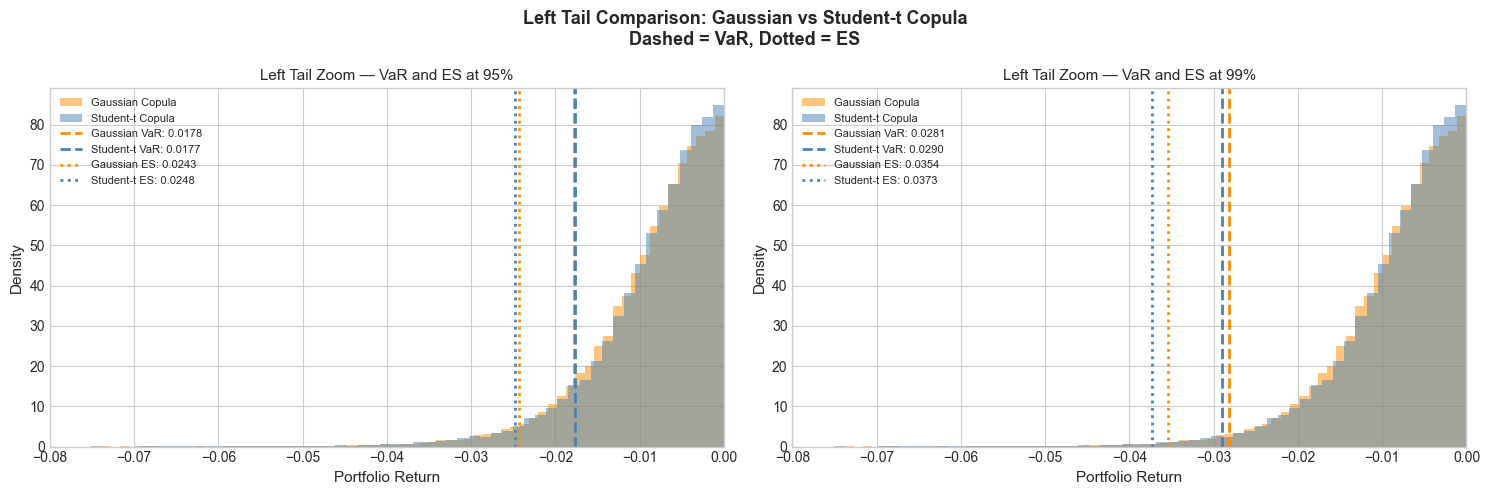

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax_idx, (alpha, conf) in enumerate(zip(ALPHA_LEVELS, ['95%', '99%'])):
    ax = axes[ax_idx]

    g_var = gaussian_results['var_es_table'].loc[conf, 'VaR']
    t_var = student_results['var_es_table'].loc[conf, 'VaR']
    g_es  = gaussian_results['var_es_table'].loc[conf, 'ES']
    t_es  = student_results['var_es_table'].loc[conf, 'ES']

    g_tail = g_returns[g_returns < 0]
    t_tail = t_returns[t_returns < 0]

    ax.hist(g_tail, bins=100, density=True, alpha=0.5,
            color='darkorange', label='Gaussian Copula')
    ax.hist(t_tail, bins=100, density=True, alpha=0.5,
            color='steelblue', label='Student-t Copula')

    ax.axvline(-g_var, color='darkorange', linewidth=2, linestyle='--',
               label=f'Gaussian VaR: {g_var:.4f}')
    ax.axvline(-t_var, color='steelblue', linewidth=2, linestyle='--',
               label=f'Student-t VaR: {t_var:.4f}')
    ax.axvline(-g_es, color='darkorange', linewidth=2, linestyle=':',
               label=f'Gaussian ES: {g_es:.4f}')
    ax.axvline(-t_es, color='steelblue', linewidth=2, linestyle=':',
               label=f'Student-t ES: {t_es:.4f}')

    ax.set_xlim(-0.08, 0)
    ax.set_xlabel('Portfolio Return', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Left Tail Zoom — VaR and ES at {conf}', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Left Tail Comparison: Gaussian vs Student-t Copula\n'
             'Dashed = VaR, Dotted = ES',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/12_tail_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

**95% panel (left)**
- VaR lines (dashed) are almost identical — confirming the two models 
  agree at moderate confidence levels
- ES lines (dotted) show a small but visible separation — Student-t ES 
  of 0.0248 vs Gaussian ES of 0.0243
- The Student-t distribution (blue) shows marginally more mass in the 
  extreme left — visible as blue bars slightly exceeding orange bars 
  beyond -0.04

**99% panel (right) — the key finding**
- VaR lines are now clearly separated: Student-t 0.0290 vs Gaussian 0.0281
- ES lines show the largest separation of all four risk measures:
  Student-t 0.0373 vs Gaussian 0.0354 — a gap of 0.0019
- The Student-t distribution (blue) has visibly more mass in the 
  extreme left tail (beyond -0.05) — this is joint tail dependence 
  directly inflating portfolio tail risk
- The ES lines sitting further left than the VaR lines illustrates 
  exactly what ES measures — the average loss in the region beyond VaR

**Why the gap widens at 99%**
At 95% we are at the edge of the tail — both copulas still assign 
similar probabilities here. At 99% we are deep in the tail where 
joint extreme co-movements become the dominant driver of losses. 
This is precisely where the Student-t copula's $\lambda = 5$–$13$% 
tail dependence coefficients produce materially different risk estimates.

**Visual confirmation of the core finding**
The tail zoom provides direct visual evidence that the Gaussian copula 
underestimates portfolio tail risk — not as a theoretical argument, 
but as an empirical observation from 100,000 simulated scenarios 
calibrated to this specific portfolio.

In [13]:
# Save results 
results_summary = pd.DataFrame({
    'Gaussian_VaR_95': [gaussian_results['var_es_table'].loc['95%', 'VaR']],
    'Gaussian_VaR_99': [gaussian_results['var_es_table'].loc['99%', 'VaR']],
    'Gaussian_ES_95':  [gaussian_results['var_es_table'].loc['95%', 'ES']],
    'Gaussian_ES_99':  [gaussian_results['var_es_table'].loc['99%', 'ES']],
    'StudentT_VaR_95': [student_results['var_es_table'].loc['95%', 'VaR']],
    'StudentT_VaR_99': [student_results['var_es_table'].loc['99%', 'VaR']],
    'StudentT_ES_95':  [student_results['var_es_table'].loc['95%', 'ES']],
    'StudentT_ES_99':  [student_results['var_es_table'].loc['99%', 'ES']],
})

results_summary.to_csv('../data/raw/var_es_results.csv', index=False)
np.save('../data/raw/gaussian_portfolio_returns.npy',
        gaussian_results['portfolio_returns'])
np.save('../data/raw/student_portfolio_returns.npy',
        student_results['portfolio_returns'])

print("Saved: var_es_results.csv")
print("Saved: gaussian_portfolio_returns.npy")
print("Saved: student_portfolio_returns.npy")

Saved: var_es_results.csv
Saved: gaussian_portfolio_returns.npy
Saved: student_portfolio_returns.npy
